In [ ]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pickle
import umap
import seaborn as sns
import sys
sys.path.insert(1, '../../')
from Harmonic_degree import *

In [3]:
# Load dictionaries
with open("../Final_outputs/df_1_ext.pkl", "rb") as f:
    df_1_ext = pickle.load(f)
    
with open("../Final_outputs/df_2_ext.pkl", "rb") as f:
    df_2_ext = pickle.load(f)

with open("../Final_outputs/df_3_ext.pkl", "rb") as f:
    df_3_ext = pickle.load(f)

with open("../Final_outputs/df_4_ext.pkl", "rb") as f:
    df_4_ext = pickle.load(f)


with open("../Final_outputs/df_5_ext.pkl", "rb") as f:
    df_5_ext = pickle.load(f)
    
with open("../Final_outputs/df_6_ext.pkl", "rb") as f:
    df_6_ext = pickle.load(f)

with open("../Final_outputs/df_7_ext.pkl", "rb") as f:
    df_7_ext = pickle.load(f)

print( len(df_1_ext) +len(df_2_ext) + len(df_3_ext) + len(df_4_ext)+ len(df_4_ext) + len(df_6_ext) + len(df_7_ext))  

50


# Plot Some of the Harmonic Values

In [7]:
all_df = {}
a = [ df_1_ext, df_2_ext, df_3_ext, df_4_ext, df_5_ext, df_6_ext, df_7_ext ]
for d in a: 
    for name, df in d.items():
        all_df[name] = df

In [10]:
df_sel = {}
nms = ["Facebook", "Web: edu", "C. Elegans", "Power: bcspwr09", "FB: Haverford76", "CS Collab"]
for name in nms:
    df_sel[name] = all_df[name]
    

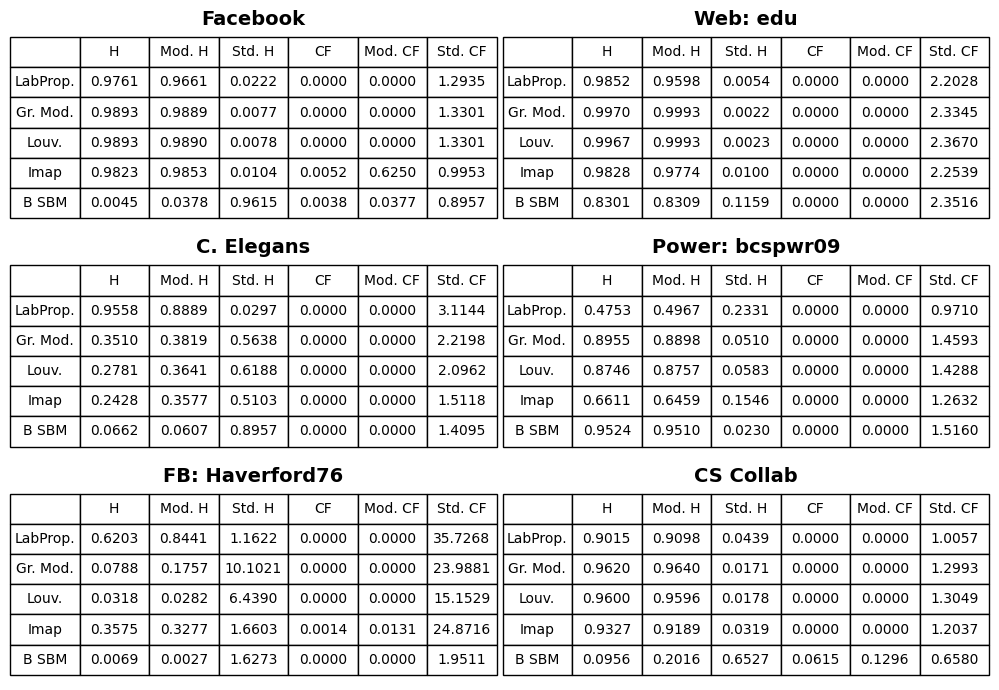

In [18]:
# Create a 2x3 subplot with an increased figure size
fig, axes = plt.subplots(3, 2, figsize=(10, 7))
axes = axes.flatten()
# Loop through DataFrames and display them in the subplot
for i, (title, df) in enumerate(df_sel.items()):
    axes[i].axis("off")  # Hide axes
    # Format values to 4 decimal places
    formatted_data = df.applymap(lambda x: f"{x:.4f}")
    # Convert DataFrame to include row labels
    table_data = formatted_data.copy()
    table_data.insert(0, "Index", table_data.index)  # Add row labels as first column
    # Create table with row and column labels
    table = axes[i].table(
        cellText=table_data.values,  # Data with row labels
        colLabels=[""] + list(df.columns),  # Empty first column for row labels
        cellLoc="center", 
        loc="center"
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.1, 1.5)  # Adjust table scaling
    # Set title closer to the table
    axes[i].set_title(title, fontsize=14, fontweight="bold", pad=5)
# Adjust layout to fit everything
plt.subplots_adjust(wspace=0.2, hspace=0.8)
plt.tight_layout()
plt.savefig("Table_example_clustering.pdf")

# Now Plot results

In [5]:
# Store DataFrames in Categories
bio = []
infrastructure = []
social = []
tech = []
animal = []
collab = []

df_bio = {}
df_infrastructure = {}
df_social = {}
df_tech = {}
df_animal ={}
df_collab = {}


for name, df in df_1_ext.items():
    if name == "E-road":
        infrastructure.append(name)
        df_infrastructure[name] = df
    elif name =="C. Elegans":
        bio.append(name)
        df_bio[name] = df
    elif ("ollab" in name) :
        collab.append(name)
        df_collab[name] = df
    else: 
        social.append(name)
        df_social[name] = df

for name, df in df_2_ext.items():
    bio.append(name)
    df_bio[name] = df


for name, df in df_3_ext.items():
    if "Oregon" in name:
        tech.append(name)
        df_tech[name] = df
    elif "ollab" in name:
        collab.append(name)
        df_collab[name] = df
    else:
        social.append(name)
        df_social[name] = df


for name, df in df_4_ext.items():
    if "Bio" in name:
        bio.append(name)
        df_bio[name] = df
    elif ("Power" in name) :
        infrastructure.append(name)
        df_infrastructure[name] = df
    elif ("Tech" in name):
        tech.append(name)
        df_tech[name] = df
    else:
        animal.append(name)
        df_animal[name] = df

for name, df in df_5_ext.items():
    if ("Tech" in name) or ("Web" in name):
        tech.append(name)
        df_tech[name] = df
    else: 
        infrastructure.append(name)
        df_infrastructure[name] = df

for name, df in df_6_ext.items():
    if "ollab" in name:
        collab.append(name)
        df_collab[name] = df
    else:
        social.append(name)
        df_social[name] = df

for name, df in df_7_ext.items():
    tech.append(name)
    df_tech[name] = df

# verify lengths are ok 
print( len(df_bio) + len(df_infrastructure)  +len(df_social) + len(df_tech)+ len(df_animal) + len(df_collab) ) 
print( len(bio) + len(social) + len(infrastructure) + len(tech) + len(df_animal) + len(df_collab) ) 

50
50


In [6]:
# modify to have just some results
for name, df in df_bio.items():
    df_bio[name] = df[["H"]]

for name, df in df_infrastructure.items():
   df_infrastructure[name] = df[["H"]]

for name, df in df_social.items():
    df_social[name] = df[["H"]]

for name, df in df_tech.items():
   df_tech[name] = df[["H"]]

for name, df in df_animal.items():
   df_animal[name] = df[["H"]]

for name, df in df_collab.items():
   df_collab[name] = df[["H"]]

In [8]:
# Define a function to extract data and labels from each dictionary
def extract_data(d):
    data_list = []
    
    for df in d.values(): 
        data_list.append(df.values.flatten())  # Flatten matrix into vector
    data = np.array(data_list)  # Convert list to numpy array
    return data

# Extract data from all dictionaries
data_bio= extract_data(df_bio)
data_infrastructure= extract_data(df_infrastructure)
data_tech = extract_data(df_tech)
data_social= extract_data(df_social)
data_animal= extract_data(df_animal)
data_collab= extract_data(df_collab)


C:\Users\Utente\anaconda3\envs\New_base\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


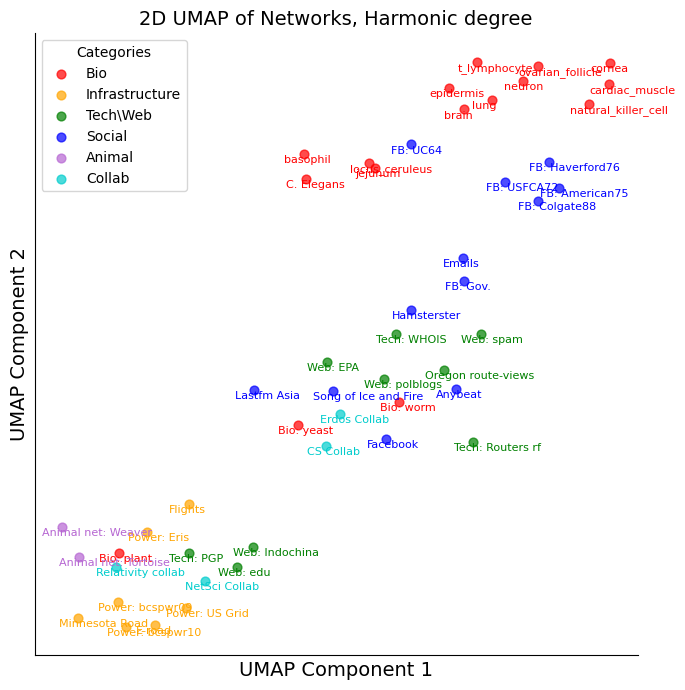

In [10]:
# Assuming you already have: data_bio, data_infrastructure, data_tech, data_social, data_animal, data_collab
X = np.vstack([data_bio, data_infrastructure, data_tech, data_social, data_animal, data_collab])
names = bio + infrastructure + tech + social + animal + collab
labels = (["Bio"] * len(bio) + ["Infrastructure"] * len(infrastructure) + 
          ["Tech\Web"] * len(tech) + ["Social"] * len(social) + 
          ["Animal"] * len(animal) + ["Collab"] * len(collab))

# UMAP embedding
umap_model = umap.UMAP(n_components=2, random_state=42)
X_umap = umap_model.fit_transform(X)

# Color mapping
group_colors = {
    "Bio": "red",
    "Infrastructure": "orange",
    "Tech\Web": "green",
    "Social": "blue",
    "Animal": "#B666D2",
    "Collab": "#00CCCC"
}

# Optional: Replace with actual importance measure if available
measure = np.ones((X.shape[0], 1))  # Dummy size scaling

# Start plot
plt.figure(figsize=(7, 7))
typecheck = {label: 0 for label in group_colors.keys()}

for i, name in enumerate(names):
    x, y = X_umap[i, 0], X_umap[i, 1]
    label = labels[i]
    color = group_colors[label]
    size = 40 * np.max(measure[i, :])  # Adjust if using real measure

    if typecheck[label] == 0:
        plt.scatter(x, y, color=color, s=size, label=label, alpha=0.7, linewidths=1)
        typecheck[label] = 1
    else:
        plt.scatter(x, y, color=color, s=size, alpha=0.7, linewidths=1)

    plt.annotate(name, (x - 0.1, y - 0.15), fontsize=8, color=color)

# Legend and styling
plt.legend(loc="best", frameon=True,title="Categories")
plt.xlabel("UMAP Component 1", fontsize=14)
plt.ylabel("UMAP Component 2", fontsize=14)
plt.title("2D UMAP of Networks, Harmonic degree", fontsize=14)

# Remove axis ticks
plt.xticks([])
plt.yticks([])

sns.despine()
plt.tight_layout()
plt.savefig("UMAP_Harmonic_styled_noticks.pdf")
